<h3>Tests audibilité signaux

1 - Préparation

In [1]:
from numpy import sin, pi, linspace
from sounddevice import play, wait

f0 =10000 #J'entends jusqu'à 16300Hz (pas de limite basse)
fe =44100
nu0 =f0
duree =3
sig_n = linspace(0,duree,fe*duree)
sig_amp = sin(2*pi*nu0*sig_n)

print(sig_amp)
play(sig_amp, fe)
wait()

[ 0.00000000e+00  9.89356993e-01  2.87919824e-01 ... -2.87919824e-01
 -9.89356993e-01 -2.91409412e-12]


In [2]:
from numpy import ones, concatenate
val = 0.0001
#Amp = [0.1 for i in range(len(sig_n)//2)]+[val for j in range(len(sig_n)//2+len(sig_n)%2)]
Amp = concatenate((0.1*ones(len(sig_n)//2),val*ones(len(sig_n)//2+len(sig_n)%2))) #concatenate nécessaire ici !
sig_amp_att = Amp*sig_amp
play(sig_amp_att,fe)
wait()


Lorsque l'amplitude est de 10-4, on n'entend plus le son. Soit par rapport au son de départ une baisse de 80 dB.

In [3]:
t_silence=0.00003
portion_silence=int(t_silence*fe)
Amp = 0.01*ones(len(sig_n))
val=0.0001
for i in range(duree): #arbitraire
    for j in range(portion_silence):
        Amp[i*fe+j]=val
    
play(sig_amp*Amp,fe)
wait()

Lorsque t-silence = 1ms, on ne repère plus les changements brutaux d'amplitude. - 1khz
C'est t_silence = 30microsecondes pour 10 kHz.

In [4]:
f0 =10000
fsaut=10060
fe =44100
duree =3
sig_n = linspace(0,duree,fe*duree)
sig_amp1 = sin(2*pi*f0*sig_n)
sig_amp2 = sin(2*pi*fsaut*sig_n)

sig_amp = concatenate((sig_amp1,sig_amp2))
play(sig_amp, fe)
wait()

Mon oreille est sensible à un saut de 2-3 Hz en fréquence pour f0 = 1kHz et un saut de 50Hz minimum pour f0 =10kHz

2 - Filtrage

In [29]:
from numpy import zeros,copy
x=concatenate((ones(1000),zeros(1000),ones(1000),zeros(1000),ones(1000),zeros(1000)))
#On prend 3 périodes, de 20000 éch resp et de rapport cyclique 1/2
x_amp=copy(x)

In [42]:
from numpy import exp,abs
def dft(seq):
    Seq=[]
    s=0
    for j in range(1,100):
        s=0
        for i in range(len(seq)):
            s= s+exp(-1j*2*pi*i*j/len(seq))*seq[i]
        Seq.append(abs(s))
    return Seq #//pk nu? Absolument pas utile??

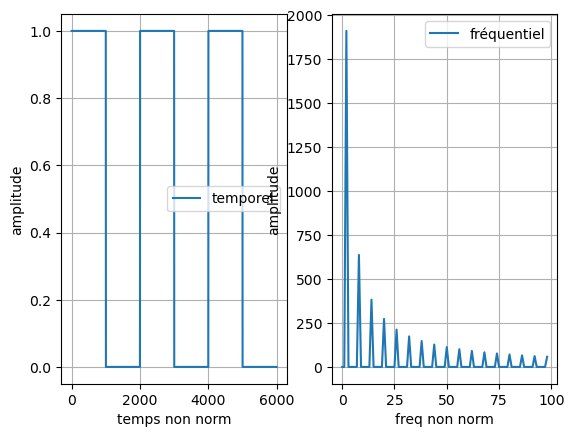

In [43]:
import matplotlib.pyplot as plt
from numpy import arange

fig, ax = plt.subplots(1,2)
ax[0].plot(arange(0,len(x)),x,label='temporel')
ax[0].set_xlabel('temps non norm')
ax[0].set_ylabel('amplitude')
ax[0].grid()
ax[0].legend()
DFT_x=dft(x)
ax[1].plot(arange(0,len(DFT_x)),DFT_x,label='fréquentiel')
ax[1].set_xlabel('freq non norm')
ax[1].set_ylabel('amplitude')
ax[1].grid()
ax[1].legend()


On obtient bien une pente de l'allure 1/n (n arbitraire)

In [12]:
import scipy.io
L=scipy.io.loadmat("TDM.mat")
print(L)

Hza_num=L['Hza_num'].flatten()
Hza_den=L['Hza_den'].flatten()
Hzb_num=L['Hzb_num'].flatten()
Hzb_den=L['Hzb_den'].flatten()
Hzc_num=L['Hzc_num'].flatten()
Hzc_den=L['Hzc_den'].flatten()


{'__header__': b'MATLAB 5.0 MAT-file Platform: nt, Created on: Fri Feb 14 19:24:44 2025', '__version__': '1.0', '__globals__': [], 'Hza_num': array([[0.11252518, 0.18206956, 0.18206956, 0.11252518]]), 'Hza_den': array([[ 1.        , -0.8053423 ,  0.43053423, -0.036     ]]), 'Hzb_num': array([[ 0.91215908, -1.07230731,  0.91215908]]), 'Hzb_den': array([[ 1.        , -1.05801345,  0.81      ]]), 'Hzc_num': array([[ 2.44502316e-06, -7.03101158e-02, -1.29037742e-06,
         9.61661893e-02, -1.06570468e-06, -3.14855511e-01,
         4.99999822e-01, -3.14855511e-01, -1.06570468e-06,
         9.61661893e-02, -1.29037742e-06, -7.03101158e-02,
         2.44502316e-06]]), 'Hzc_den': array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])}


Vu que l'ordre du den n'est pas nul, on en déduit que ce sont des filtres IIR (sauf le dernier, c'est un FIR). Les filtres sont supposés causaux (pas le cas si au dénominateur/au numérateur le premier terme est nul) (il y a aussi des cas pouvant paraître bon qui ne le sont pas). Tous LTIS donc.
L'ordre se trouve au  num!!!